# Generalizando distância

Vários algoritmos de aprendizado de máquina baseados em distância são genéricos o suficiente para mudarmos a forma como calculamos a distância entre dois pontos. Quando olhamos para dados em $\mathbb{R}^n$, para $n\in\mathbb{N}^*$, estamos acostumados com a **distância euclidiana**. Essa distância calcula o tamanho do comprimento de reta que liga os dois pontos, com uma espécie de generalização do teorema de Pitágoras.

Explicitamente temos, para $\textbf{x} = (x_1, x_2, \cdots, x_n) \in \mathbb{R}^n$ e $\textbf{y} = (y_1, y_2, \cdots, y_n) \in \mathbb{R}^n$, a distância dada por

$$
\begin{equation*}
 \textrm{distância euclidiana entre }\textbf{x}\textrm{ e }\textbf{y} = \sqrt{ \sum_{i=1}^{n} |x_i-y_i|^2  } .
\end{equation*}
$$

Entretanto, dependendo da natureza do problema essa distância pode não ser a mais indicada. Neste post, vamos conversar sobre a definição de distância aos olhos de conceitos básicos de topologia de espaços métricos e exemplificar algumas métricas clássicas entendendo a diferença entre elas. Essa discussão pode ser importante para se aprofundar em algoritmos clássicos que utilizam um cálculo de distância como o kNN, o DBScan e o k-means e suas variações. Além de aprender a identificar outros momentos em que você pode utilizar o conceito de distância.

# Definindo formalmente a distância entre dois pontos

Intuitivamente, uma distância precisa satisfazer algumas propriedades que surgem da forma como vemos distância intuitivamente. Iremos ver uma definição matemática para ela que tenta sintetizar essas noções em termos matematicamente claros.

Primeiro, é razoável pedir *simetria*: a distância de $x$ até $y$ seja igual à distância de $y$ até $x$. Isso parece óbvio, mas a nossa definição formal de distância será uma função que aceita duas entradas e retorna um valor, que chamaremos de distância entre os argumentos de entrada. Essa primeira propriedade desejada nos dirá que não importa a ordem em que damos as entradas.

Uma outra propriedade desejável é a *identidade*: a distância de um ponto até ele mesmo é zero e se dois pontos estão a uma distância zero então eles são o mesmo elemento. Isso também é bem razoável e nos diz que apenas o próprio ponto tem distância zero dele mesmo.

Por fim, no ensino fundamental nos dizem que, dado um triângulo, então a soma dos comprimentos de dois lados sempre é maior ou igual ao comprimento do lado restante para o triângulo ser válido. Vamos querer manter essa propriedade na nossa definição formal de distância, chamando essa propriedade de *desigualdade triangular*.

Com essa noção intuitiva de distância, criamos a formalização dada pela definição matemática:

**Definição**: Dado um conjunto $\mathcal{A}$, uma função $d:\mathcal{A}\times\mathcal{A}\to \mathbb{R}$ é chamada de uma **métrica** (ou **distância**) em $\mathcal{A}$ se, dados $x,y,z\in\mathcal{A}$ quaisquer, satisfaz:

$$
\begin{aligned}
&d(x,y) = 0 \Leftrightarrow x = y \quad \textrm{(identidade)};\\
&d(x,y) = d(y,x) \quad \textrm{(simetria)};\\
&d(x,y) + d(y,z) \geq d(x,z) \quad \textrm{(desigualdade triangular)}.
\end{aligned}
$$

Repare que dessas propriedades, tiramos ainda outras propriedades desejadas, como, por exemplo, a *não-negatividade*. Seria contraintuitivo medir a distância entre dois pontos e obter um número negativo. Para mostrar que isso vale no nosso caso, ou seja, que $d(x,y)\geq 0$ para quaisquer $x,y\in \mathcal{A}$, usamos a desigualdade triangular: $d(x,y) + d(y,x) \geq d(x,x)$. Pela simetria e usando que $d(x,x)=0$ temos que $2 \, d(x,y) \geq 0$, e concluímos o desejado.

Definimos que, dada uma função métrica $d$ como anteriormente, a **distância entre dois pontos** $x,y\in \mathcal{A}$ é dada por $d(x,y)$.

# Exemplos clássicos para $\mathbb{R}^n$

A natureza e escolha da métrica varia de acordo com o problema estudado. Em geral, quando $\mathcal{A}=\mathbb{R}^n$, estamos interessados em **distâncias induzidas pelas normas Lp** (com $1\leq p \leq \infty$) dadas na forma

$$
\begin{equation*}
d_p(\textbf{x},\textbf{y}) = || \textbf{x} - \textbf{y} ||_p,
\end{equation*}
$$

com soma de vetores coordenada a coordenada em que a norma Lp $||\cdot||_p : \mathbb{R}^n \to \mathbb{R} $ é dada por

$$
\begin{equation*}
 ||\textbf{x}||_p = \left( \sum_{i=1}^{n} |x_i|^p  \right)^{\frac{1}{p}}.
\end{equation*}
$$

As métricas dessa família de distâncias, no contexto de aprendizado de máquina, são mais conhecidas como **distância Minkowski com parâmetro p**. Repare que a distância euclidiana usual é a distância de Minkowski com parâmetro 2. O caso limite, quando $p=\infty$, é definido como o maior valor absoluto entre as coordenadas, ou seja,

$$
\begin{equation*}
||\textbf{x}||_{\infty} = \max_{1\,\leq \,i \,\leq \,n} |x_i|.
\end{equation*}
$$

A métrica $d_\infty$ é também conhecida como **distância de Chebyshev** ou **do máximo**. Um outro nome clássico para a métrica $d_1$ é **distância de Manhattan**.

## Diferentes bolas do $\mathbb{R}^n$

Para ilustrar como essas diferentes formas de medir distância funcionam, vamos definir um conceito primordial de topologia de espaços métricos: a bola aberta. A noção de bola tenta dar um significado para a pergunta: *"O que significa ter um elemento perto de outro?"*.

Primeiro, teremos um parâmetro relacionado com o ponto central de comparação. Este será o elemento com o qual compararemos os outros, tentando responder se estão próximos ou não. Além disso, o significado de perto depende da nossa tolerância: duas pessoas sentadas a menos de 1 metro é perto (ainda mais em época de coronavírus), mas um meteoro a 1 quilômetro da Terra também é perto aos olhos de um astrônomo. A nossa bola também terá um parâmetro, que chamaremos de *raio*, que nos dará até quanto estamos considerando perto.

**Definição:** Seja $d$ uma métrica em um conjunto $\mathcal{A}$. Uma **bola aberta** de raio $r>0$ centrada no ponto $x\in \mathcal{A}$ é o conjunto

$$
B_d(x;r) = \{ y\in \mathcal{A} : d(x,y) \lt r\}.
$$

Os elementos de $B_d(x;r)$ são os elementos de $\mathcal{A}$ perto de $x$ (sob essa tolerância de raio $r$). Essa noção de perto, formalizada pela bola, ajuda a definir o significado de convergência e continuidade em espaços abstratos, mas não entraremos nesses tópicos.

Vamos brincar com o formato dessas bolas quando $\mathcal{A}=\mathbb{R}^2$ e $d=d_p$, a distância de Minkowski de parâmetro $p$, variando o valor do $p$. Essas métricas já estão implementadas no [`sklearn.metrics.DistanceMetric`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html), vamos apenas criar uma função que recebe uma métrica, um raio e um centro, e plota a bola associada.

In [1]:
# nb2post: skip
%matplotlib inline
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np

cmap = clr.LinearSegmentedColormap.from_list("custom blue", ["#565b70", "#fd3712"], N=256)

In [2]:
from sklearn.metrics import DistanceMetric


def open_ball(metrics, radius=1, center=[0, 0], titles=None):
    """Plot the unit balls (up to three per row) of the metrics in `metrics`.

    metrics: list of sklearn.metrics.DistanceMetric objects.
    radius: ball radius (float) or a list of radii, one per metric.
    center: shared center of the balls, [x, y]. Axes always between -1.5 and 1.5.
    titles: optional list of subplot titles, one per metric.
    """
    if type(radius) in [int, float]:
        radius = [radius] * len(metrics)

    # grid used to draw the level curve of the indicator function
    # (which tells whether the point is inside or outside the ball)
    x_vals = np.linspace(-1.5, 1.5, 400)
    y_vals = np.linspace(-1.5, 1.5, 400)
    X, Y = np.meshgrid(x_vals, y_vals)

    n = len(metrics)
    m = int(np.ceil(len(metrics) / 3))
    plt.figure(figsize=(12, 4 * m))

    for j, metric in zip(range(1, n + 1), metrics):
        plt.subplot(m, 3, j)

        # indicator function: 1 if the point is inside the ball, 0 otherwise
        Z = np.asarray(
            [
                [
                    1
                    if metric.pairwise(np.array([[x, y]]), np.array([center]))[0, 0] < radius[j - 1]
                    else 0
                    for x in x_vals
                ]
                for y in y_vals
            ]
        )
        plt.contourf(X, Y, Z, levels=[-0.1, 0.1, 0.9, 1.1], cmap=cmap)
        plt.xticks([-1, 0, 1])
        plt.yticks([-1, 0, 1])
        if titles is not None:
            plt.title(titles[j - 1])

Os plots abaixo mostram como varia o formato da bola centrada na origem e de raio 1 para $p = 1$, $1.5$, $2$, $3$, $10$, $\infty$, em ordem.

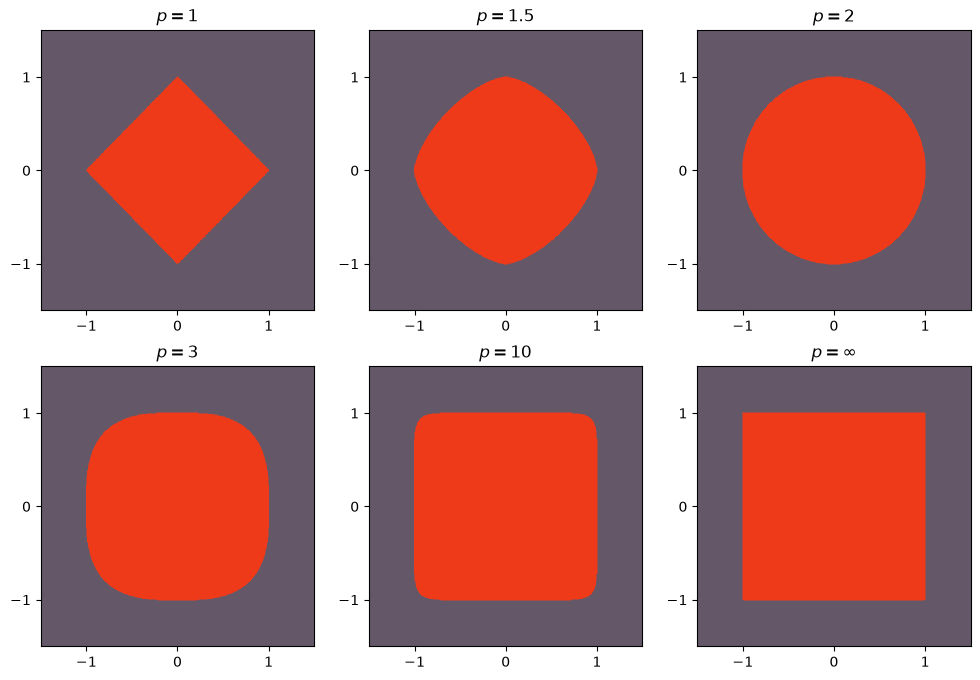

In [3]:
ps = [1, 1.5, 2, 3, 10]
metrics = []
for p in ps:
    metrics.append(DistanceMetric.get_metric("minkowski", p=p))
metrics.append(DistanceMetric.get_metric("chebyshev"))

titles = [f"$p = {p}$" for p in ps] + [r"$p = \infty$"]
open_ball(metrics, titles=titles)

A borda da nossa bola não está incluída nela, daí o nome aberta, análogo aos intervalos abertos da reta que não contêm os elementos da fronteira (de fato, um intervalo aberto é uma bola aberta na reta). De toda forma é interessante analisar a borda para entender seus diferentes formatos. Como temos $r=1$ e o centro como sendo a origem, vale que a borda é dada pelos valores $(x_1,x_2)\in\mathbb{R}^2$ que satisfazem a equação

$$
\begin{equation*}
|x_1|^p + |x_2|^p = 1.
\end{equation*}
$$

Quando $p=2$, temos o círculo, da nossa noção euclidiana de bola. Mas repare que quando $p=1$, temos quatro retas, dependendo do sinal de $x_1$ e $x_2$ e por isso obtemos o losango. O caso $p=\infty$ é dado por

$$
\begin{equation*}
\max\{|x_1|, |x_2|\} = 1,
\end{equation*}
$$

e é por isso que temos a borda nos valores dos pontos que tem $|x_1|=1$ ou $|x_2|=1$.

Eu nunca vou entender qual a graça do programa Chaves, mas impossível não fazer um comentário infeliz sobre as bolas quadradas do Kiko estarem na verdade utilizando a métrica de Chebyshev. O Kiko, como você agora, entende bastante de topologia de espaços métricos.

# Mais exemplos

Vamos passar por mais alguns exemplos interessantes que podem ajudar a construir a intuição ou que são relevantes no contexto de ciência de dados.

## Métrica discreta

Imagine um experimento exótico em que o valor explícito da distância entre dois pontos não é importante, mas é relevante saber se dois elementos são iguais ou não. Nesse cenário, a **métrica discreta** pode ser útil. Dado $\mathcal{A}$ qualquer, a distância $d_{\textrm{disc}}$ entre $x,y\in\mathcal{A}$ é dada por

$$
\begin{equation*}
d_{\textrm{disc}}(x,y)=
\begin{cases}
0 \textrm{, se }x=y,\\
1 \textrm{, caso contrário.}
\end{cases}
\end{equation*}
$$

É um exercício legal se convencer que esta forma de distância satisfaz as propriedades que desejávamos na definição de métrica.

Aqui, a noção de perto ou distante se torna um pouco contraintuitiva. Se $\mathcal{A}=\mathbb{R}^2$, então o ponto $(0,0)$ está a mesma distância do ponto $(0,1)$ e do ponto $(42,-42)$. Podemos olhar isso analisando as bolas para diferentes valores do raio $r$. Para qualquer $r\in (0,1]$, temos que $B_{d_{\textrm{disc}}}(x;r) = \{ x \}$, pois somente $x$ está a uma distância menor que 1 dele mesmo. Agora, para qualquer $r\in (1,\infty)$ temos que $B_{d_{\textrm{disc}}}(x;r) = \mathcal{A}$ uma vez que qualquer ponto está a uma distância menor ou igual a 1 de $x$.

No [`sklearn.metrics.DistanceMetric`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html), podemos passar uma métrica genérica que respeite a definição que fizemos na definição formal. Usando o argumento `pyfunc` e estabelecendo a função métrica em `func` que recebe dois vetores numpy unidimensionais e retorna a distância entre eles.

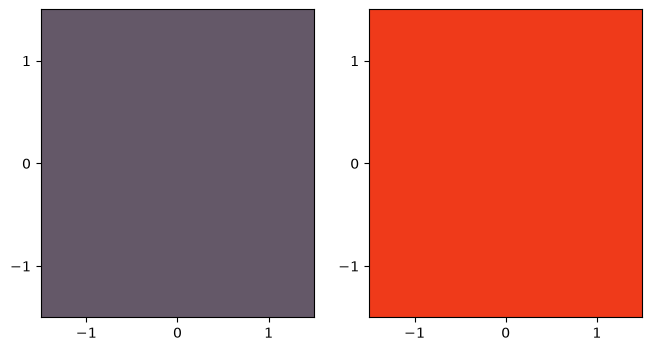

In [4]:
def discrete(X, Y):
    """Discrete distance between X and Y: 0 if they are equal, 1 otherwise."""
    if np.all(X == Y):
        return 0
    else:
        return 1


open_ball([DistanceMetric.get_metric("pyfunc", func=discrete)] * 2, [0.5, 1.5])

Na figura abaixo, passamos como raios das bolas os valores $0.5$ e $1.5$, para ver o efeito discutido anteriormente de que $B_{d_{\textrm{disc}}}((0,0);0.5)=\{(0,0)\}$ e $B_{d_{\textrm{disc}}}((0,0);1.5)=\mathbb{R}^2$.

## Distância de Hamming

A **distância de Hamming** entre dois vetores de tamanho $n$ é o número de componentes diferentes entre eles. Ela se demonstra muito útil quando os valores das componentes não são numéricos ou não têm um sentido de ordem. Vamos dar um cenário em que pode fazer sentido usá-la:

### Distância entre panelas

Imagine que eu queira descrever a distância entre duas panelas e os atributos que eu considero importante sobre esse objeto são a cor e a presença ou não de cabo. Neste caso, estamos representando nosso espaço como $\mathcal{A} =$ $\{ \textrm{cinza}, \textrm{vermelha}, \textrm{preta}  \}$ $\times \{\textrm{tem cabo}, \textrm{não tem cabo} \}$. Uma panela é representada por um vetor de duas componentes, na primeira a sua cor e na segunda a presença de cabo, por exemplo $(\textrm{cinza}, \textrm{tem cabo})$.

A maneira como vimos distância até agora apenas falava sobre números. Podemos adaptar $\mathcal{A}$ para analisar o espaço $\mathcal{A}' =\{1,2,3\}\times\{1,2\}$ em que fazemos a bijeção entre os elementos pelo mapa ($\textrm{cinza}\to 1$, $\textrm{vermelha}\to 2$, $\textrm{preta}\to 3$) e ($\textrm{tem cabo}\to 1$, $\textrm{não tem cabo}\to 2$). Com essa transformação, podemos usar por exemplo a distância de Minkowski com parâmetro 1.

Imagine que temos $\textrm{panela}_1 = (\textrm{cinza},\textrm{tem cabo})$, $\textrm{panela}_2 = (\textrm{preta},\textrm{tem cabo})$, e $\textrm{panela}_3 = (\textrm{vermelha},\textrm{não tem cabo})$. Neste caso, ficaríamos com coisas do tipo:

$$
\begin{aligned}
d_{\textrm{panelas}}(\textrm{panela}_1, \textrm{panela}_2 ) &= d_1((1,1),(3,1)) = |1-3|+|1-1| = 2,\\
\textrm{enquanto}\quad d_{\textrm{panelas}}(\textrm{panela}_1, \textrm{panela}_3 ) &= d_1((1,1),(2,2)) = |1-2|+|1-2| = 2.
\end{aligned}
$$

Esta forma de calcular distâncias, está nos falando que a $\textrm{panela}_1$ está a mesma distância da $\textrm{panela}_2$ e da $\textrm{panela}_3$. A $\textrm{panela}_1$ difere da $\textrm{panela}_2$ apenas pela cor, enquanto difere em cor e na presença de cabo da $\textrm{panela}_3$. O problema surgiu aqui porque levamos as cores pra reta como se esses objetos tivessem uma ordem, o que não faz sentido aqui.

Uma alternativa é justamente calcular a distância Hamming das panelas, somando $1$ na distância pra cada categoria (cor e presença de cabo) em que há diferença. Neste caso a distância de Hamming da $\textrm{panela}_1$ e a $\textrm{panela}_2$ seria 1 pois diferem apenas na primeira componente.

$\oint$ *A distância de Hamming é equivalente a fazer um [`sklearn.preprocessing.OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) de cada uma das componentes dos vetores e depois calcular a distância com qualquer Minkowski (dividindo por 2 o resultado final).*

## Distância do ângulo

Imagine que $\mathcal{A}= S^{\,1} =\{ (a,b)\in\mathbb{R}^2 : a^2 + b^2 = 1 \}$, ou seja, estamos olhando exatamente para os vetores do plano de norma L2 igual a 1, o círculo tradicional que conhecemos. Podemos definir uma **distância do ângulo** dada pelo ângulo entre dois pontos. Por exemplo, a distância entre $(0,1)$ e $(1,0)$ seria $\pi/2$, uma vez que o ângulo entre estes dois vetores é $90^\circ$. Uma forma explícita de calcular esse ângulo é

$$
\begin{equation*}
d_{\textrm{ang}}((x_1,x_2),(y_1,y_2)) = \arccos \left( x_1\,y_1 + x_2 \,y_2\right),
\end{equation*}
$$

em que o argumento do arco cosseno é justamente o produto interno entre os vetores.

É importante reparar que fizemos a restrição de olhar apenas para vetores de tamanho $1$ pra satisfazer a definição de métrica que fizemos. Olhar o ângulo entre vetores de tamanho qualquer não nos dá uma métrica pois não temos a propriedade de identidade: o ângulo entre os vetores $(1,0)$ e $(2,0)$ é $0$ entretanto $(1,0)\neq (2,0)$. Além disso, não é possível definir o ângulo entre um vetor qualquer e o vetor nulo.

Podemos generalizar essa distância para vetores em dimensões maiores na superfície de uma hiperesfera unitária $\mathcal{A} = S^{\,n-1} = \{ \textbf{x}\in\mathbb{R}^n : ||\textbf{x}||_2 = 1 \}$. Calculamos a  distância entre $\textbf{x} = (x_1, x_2, \cdots, x_n)$ e $\textbf{y} = (y_1, y_2, \cdots, y_n)$, como

$$
\begin{equation*}
d_{\textrm{ang}}(\textbf{x},\textbf{y}) = \arccos \left( \sum_{i=1}^n x_i\,y_i\right).
\end{equation*}
$$

Esta forma de definir distância satisfaz as propriedades desejadas, mas não é fácil ver por que a desigualdade triangular é realizada fora de $S^1$ *($\oint$ caso conheça um pouco de geometria diferencial, a ideia é que esta definição é a métrica geodésica na hiperesfera unitária)*.

A distância do ângulo está intimamente relacionada à "distância do cosseno", muito usada em ciência de dados, definida como $1$ menos o cosseno do ângulo entre os vetores (ou seja, $1$ menos o produto interno entre os vetores normalizados). A distância do cosseno, de fato, não é uma métrica, pois não satisfaz a definição matemática (em particular, a desigualdade triangular). Entretanto, isso não a torna descartável. Em muitos casos, uma medida de (dis)similaridade entre pontos — que define o quão parecidos ou diferentes eles são — já é suficiente para resolver o problema. Em outros casos, será importante satisfazer todas as definições vistas anteriormente.

### Distância entre documentos

Essa métrica é tradicionalmente usada em discussões iniciais sobre distância entre dois textos. Primeiro, temos que pensar em uma representação numérica para um texto. Uma maneira inicial é pensar no texto como uma *bag of words*, desprezando a ordem das palavras, letras maiúsculas e pontuações, mas levando em conta a frequência de cada palavra no texto.

Neste caso, $\mathcal{A} = \mathbb{N}^{t}$, em que $t$ é o número total de palavras diferentes que aparecem no *corpus* (conjunto de todos os documentos) que desejamos calcular as distâncias. Cada componente está associada com uma dessas palavras. Um texto é um vetor de $\mathcal{A}$ em que cada elemento nos dá quantas vezes aquela palavra ocorre no texto.

Fica mais fácil ver isso com um exemplo: Suponha que nosso *corpus* é dado pelos textos $\{$ $\textrm{texto}_1 = $ *"Olá, bom dia, bom dia."*,  $\textrm{texto}_2 = $ *"Bom dia!"*$\}$. Neste caso, temos o mapa: $\{1\to$ *ola*, $2\to$ *bom*, $3\to$ *dia*$\}$ indicando cada componente do vetor de $\mathbb{N}^{\,3}$ (repare que aqui ignoramos pontuação, letras maiúsculas e acentos). Ficamos com

$$
\begin{equation*}
\{ \textrm{texto}_1 = (1,2,2),  \textrm{texto}_2 = (0,1,1)\}
\end{equation*}
$$

Com esta representação numérica, a princípio, podemos usar qualquer métrica vista anteriormente. Uma motivação para usar a distância do ângulo é assumir que textos parecidos usam as mesmas palavras com uma frequência parecida de vezes. Portanto, apontam na mesma direção da nossa representação.

A ideia agora é normalizar os vetores e estamos prontos para calcular a distância. A distância, neste caso é dada por

$$
\begin{equation*}
d_{\textrm{ang}}(\textrm{texto}_1, \textrm{texto}_2) = \arccos \left( \frac{1\cdot0 + 2\cdot1 + 2\cdot 1}{\sqrt{5} \,\cdot \sqrt{2} }  \right) = 0.369\pi.
\end{equation*}
$$

In [5]:
# nb2post: skip
np.arccos(4 / (5 * 2)) / np.pi

np.float64(0.36901011956554536)

Considerando que essa distância vale no mínimo 0 e no máximo $\pi$, temos textos razoavelmente parecidos.

$\oint$ *Essa abordagem apresenta inúmeras simplificações que fazem a gente perder a qualidade da resposta. Por exemplo, sabemos que palavras diferentes podem significar a mesma coisa (ou conjugações diferentes, plurais etc). Palavras iguais em contextos diferentes podem ter significados diferentes. Existem palavras comuns a vários textos ou que ocorrem muitas vezes no mesmo texto que podem não ser úteis. Em muitos casos a ordem das palavras é muito importante e muda o sentido de uma frase (como usar a palavra "não"). Entre outros problemas.*

## Distância entre funções contínuas

Seja agora $\mathcal{A}=C^{\,0}[a,b] = \{f \in \mathbb{R}^{[a,b]}: f \textrm{ contínua}\}$, o conjunto das funções contínuas com domínio $[a,b]\subset\mathbb{R}$ e contradomínio $\mathbb{R}$.  Podemos definir a distância entre as funções $f,g\in\mathcal{A}$ como

$$
\begin{equation*}
d_{\max}(f,g) = \max_{x \,\in \,[a,b]} |f(x) - g(x)|.
\end{equation*}
$$

Ou seja, a distância entre duas funções é dada pelo máximo do módulo da diferença em cada ponto do intervalo $[a,b]$.

Por exemplo, se queremos calcular a distância entre as funções $f$ e $g$ definidas no intervalo $[0,1]$ tais que $f(x)=(x-0.4)^2$ e $g(x) = 2.5$, temos que achar o valor que maximiza a função $h(x) = | (x-0.4)^2 - 2.5|$, plotada na primeira imagem da figura abaixo. Isso nem sempre é uma tarefa fácil, pois não temos nenhuma hipótese sobre a diferenciabilidade das nossas funções e o módulo atrapalha ainda mais criando novos picos. Na segunda imagem da figura abaixo temos uma interpretação visual do que queremos. O valor da distância será o local em que as curvas estão mais distantes.

In [6]:
# nb2post: skip
def f1(x):
    return [2.5] * len(x)


def f2(x):
    return 9 * (x - 0.4) ** 2


def f3(x, radius):
    return 9 * (x - 0.4) ** 2 + radius


def f4(x):
    return 9 * (x - 0.4) ** 2 + 0.4 * np.sin(30 * x)


def f5(x):
    return np.abs(np.asarray(f1(x)) - f2(x))

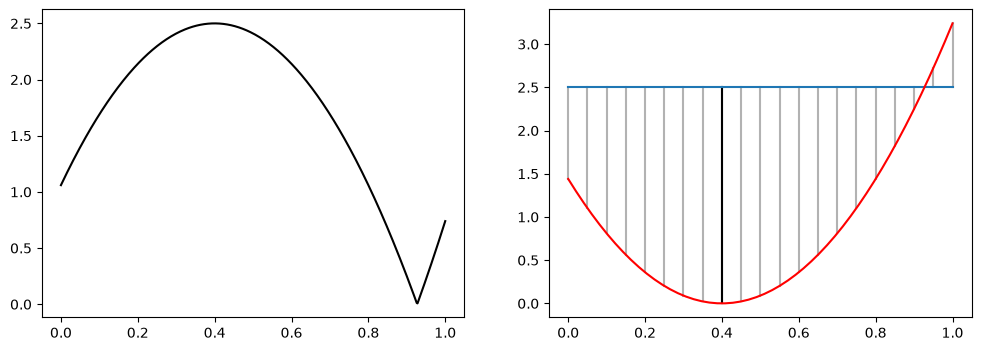

In [7]:
# nb2post: skip-input
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0, 1, 500), f5(np.linspace(0, 1, 500)), "k")
plt.subplot(1, 2, 2)
for x in np.linspace(0, 1, 21):
    plt.plot([x, x], [2.5, f2(x)], "grey", alpha=0.6)
plt.plot([0.4, 0.4], [2.5, f2(0.4)], "k")
plt.plot(np.linspace(0, 1), f1(np.linspace(0, 1)))
plt.plot(np.linspace(0, 1), f2(np.linspace(0, 1)), "r")
plt.show()

Nessa métrica, a bola de raio $r>0$ ao redor da função $f:[a,b]\to\mathbb{R}$ são todas as funções (definidas no intervalo $[a,b]$) que ficam sempre dentro da faixa ao redor de $f$ de largura $2r$. Na figura abaixo temos um exemplo disso. A função $g(x) = (x-0.4)^2 + 0.4\sin(30x)$ está dentro da bola $B_{d_{\max}}((x-0.4)^2;0.5)$ pois a distância entre elas é $\max_{x\in[0,1]} |0.4 \sin(30x) |=0.4<0.5$.

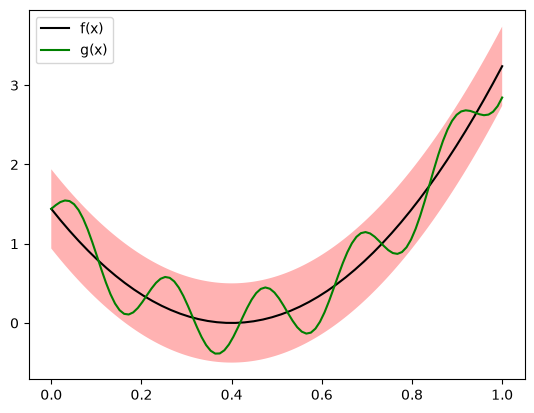

In [8]:
# nb2post: skip-input
radius = 0.5

x = list(np.linspace(0, 1, 400)) + list(np.linspace(1, 0, 400))
y = []
for i in range(len(x)):
    if i < len(x) / 2:
        y.append(f3(x[i], radius))
    else:
        y.append(f3(x[i], -radius))
plt.fill(x, y, "r", alpha=0.3)

plt.plot(np.linspace(0, 1), f2(np.linspace(0, 1)), "k", label="f(x)")
plt.plot(np.linspace(0, 1, 100), f4(np.linspace(0, 1, 100)), "g", label="g(x)")
plt.legend()
plt.show()

$\oint$ *O teste KS usa uma variação dessa métrica pra definir uma distância entre variáveis aleatórias a partir da distância entre as funções densidade acumulada.*

## Distância Ponderada

Em muitos casos pode ser importante atribuir um peso maior para alguma das coordenadas, surgindo a ideia da **distância ponderada**. Por exemplo, se $\mathcal{A}=\mathbb{R}^2$ e estar perto na primeira coordenada é $10$ vezes mais importante do que estar perto na segunda, podemos fazer uma variação da métrica Euclidiana para calcular a distância entre $\textbf{x} = (x_1,x_2)$ e $\textbf{y}=(y_1,y_2)$ como

$$
\begin{equation*}
 d_{\textrm{ponderada}}(\textbf{x},\textbf{y}) = \sqrt{10 (x_1-y_1)^2 +(x_2-y_2)^2 }\,.
\end{equation*}
$$

Não entraremos em detalhes, mas podemos fazer isso sempre que temos uma matriz $A$ [positiva definida](https://pt.wikipedia.org/wiki/Matriz_positiva_definida) definindo

$$
\begin{equation*}
 d_{\textrm{ponderada}}(\textbf{x},\textbf{y}) = \sqrt{(\textbf{x}-\textbf{y})^T \, A \,(\textbf{x}-\textbf{y}) }\,,
\end{equation*}
$$

fazendo as operações usuais de multiplicação de vetores linha, coluna e matrizes. Portanto, fixada $A$, podemos implementar essa métrica para usar a função `open_ball` como fizemos com a métrica discreta.

In [9]:
def weighted(X, Y):
    """Weighted distance between X and Y for a positive-definite matrix A."""
    return np.dot(X - Y, np.matmul(A, X - Y))

Uma matriz com todos valores da diagonal positivos é sempre uma matriz positiva definida. Neste caso podemos interpretar os valores da diagonal como os pesos que queremos dar em cada uma das coordenadas. A distância euclidiana usual ocorre quando $A$ é a matriz identidade. Já o caso estudado anteriormente ocorre quando

$$
A = \left[\begin{array}{cc} 10 & 0 \\ 0 & 1 \end{array}\right].
$$

Podemos brincar com essas diferentes matrizes colocando pesos nas coordenadas que consideramos mais importantes. Valores fora da diagonal principal podem ser interpretados como uma interação entre aquelas coordenadas. Eles vão distorcer o formato da bola, como podemos ver abaixo em que temos, respectivamente, as matrizes positivas definidas

$$
A= \left[\begin{array}{cc} 2 & 0 \\ 0 & 1 \end{array}\right], \left[\begin{array}{cc} 2 & -1 \\ -1 & 2 \end{array}\right]\textrm{, e }\left[\begin{array}{cc} 1 & -1 \\ -1 & 4 \end{array}\right].
$$

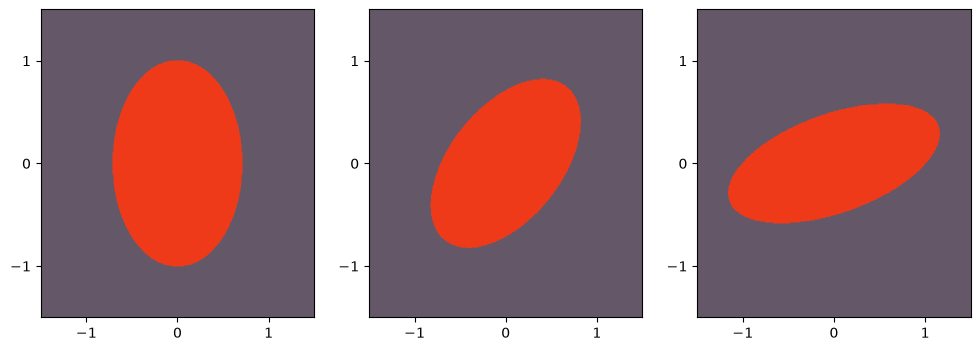

In [10]:
# nb2post: skip-input
def weighted1(X, Y):
    return np.dot(X - Y, np.matmul(np.asarray([[2, 0], [0, 1]]), X - Y))


def weighted2(X, Y):
    return np.dot(X - Y, np.matmul(np.asarray([[2, -1], [-1, 2]]), X - Y))


def weighted3(X, Y):
    return np.dot(X - Y, np.matmul(np.asarray([[1, -1], [-1, 4]]), X - Y))


open_ball(
    [
        DistanceMetric.get_metric("pyfunc", func=weighted1),
        DistanceMetric.get_metric("pyfunc", func=weighted2),
        DistanceMetric.get_metric("pyfunc", func=weighted3),
    ]
)

___

# Explicabilidade por referência

A noção de distância é um conceito muito importante. Ela é um jeito intuitivo de nos dar uma noção de **similaridade** (e **dissimilaridade**) entre exemplos. No contexto de aprendizado supervisionado, se sua forma de calcular distância é razoavelmente compreensível, modelos que funcionam através de encontrar vizinhos próximos tornam-se **explicáveis por referência**. Se queremos entender o motivo dele ter dado determinada previsão para um exemplo, olhamos para os dados do treino parecidos com a observação que estamos avaliando.

Colocando em um exemplo, suponha que temos um problema de classificação binária em que estamos tentando prever se um cliente é inadimplente ou não. Usar estratégias que encontram vizinhos próximos na base de treinamento nos dá explicações para a resposta de um determinado cliente. Estamos olhando clientes com atributos parecidos (segundo nossa distância) e fazendo a previsão a partir deles. Se queremos saber por que um determinado cliente foi considerado inadimplente, olhamos para os vizinhos mais próximos e entendemos por que o modelo deu o resultado que deu.

___

Espero que este post, muito divertido de escrever, tenha sido útil para entender melhor o que significa distância e as diferenças entre elas. No mínimo, agora você pode usar algumas das métricas que discutimos aqui como um dos hiper-parâmetros dos seus modelos baseados em distância!

*$\oint$ Nem sempre a troca é imediata. No k-means, por exemplo, a atualização dos centroides é a média dos exemplos daquele cluster justamente porque a média minimiza a função custo dada pela soma das distâncias euclidianas dos exemplos até os seus respectivos centroides. Se escolhemos minimizar a soma das distâncias de Minkowski de parâmetro 1 (L1), então a atualização dos centroides é feita com a mediana coordenada a coordenada uma vez que estes são os valores que minimizam a função de custo alterada, este é o K-Medians.*

___